Ejercicio evaluación Módulo 3

Fase 3: Visualización

In [1]:
# importamos las librerías que necesitamos
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None) # para poder visualizar todas las columnas de los DataFrames

In [2]:
df = pd.read_csv("files/customer_flight_activity_limpio.csv") # para cargar el archivo CSV "customer_flight_activity.csv" en un DataFrame llamado df, lo que nos permitirá trabajar con los datos de actividad de los clientes de vuelos en Python utilizando la biblioteca pandas.

In [3]:
df.head()

,loyalty_number,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed,status
0,480934,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236,Married,Star,3839.14,Standard,2016,2,NaN,NaN,2017,1,0,0,0,0,0.0,0,0,active
1,480934,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236,Married,Star,3839.14,Standard,2016,2,NaN,NaN,2017,2,3,0,3,2823,282.0,0,0,active
2,480934,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236,Married,Star,3839.14,Standard,2016,2,NaN,NaN,2017,3,0,0,0,0,0.0,0,0,active
3,480934,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236,Married,Star,3839.14,Standard,2016,2,NaN,NaN,2017,4,0,0,0,0,0.0,0,0,active
4,480934,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236,Married,Star,3839.14,Standard,2016,2,NaN,NaN,2018,10,6,2,8,3352,335.0,465,38,active


In [24]:
#¿Cómo se distribuye la cantidad de vuelos reservados por mes durante el año?

round(df.groupby("month")["total_flights"].mean(), 2)

month
1     3.56
2     3.53
3     4.82
4     4.14
5     5.29
6     6.45
7     7.29
8     6.31
9     5.09
10    4.84
11    4.52
12    6.20
Name: total_flights, dtype: float64

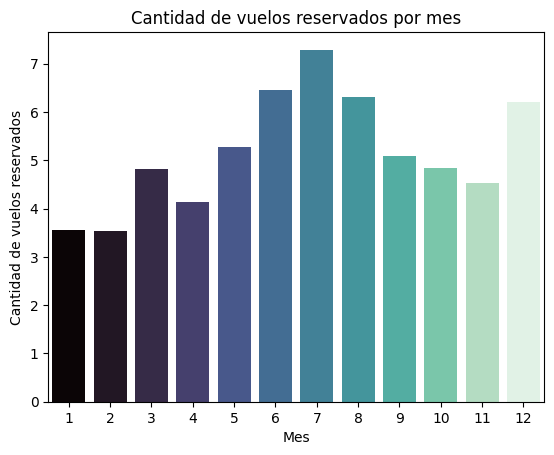

In [ ]:
sns.barplot(data=df, x="month", y="total_flights", palette="mako", hue= "month", legend=False, errorbar=None)# para crear un gráfico de barras que muestre la cantidad promedio de vuelos reservados por mes, utilizando la columna "month" para el eje x y la columna "total_flights" para el eje y, con una paleta de colores "mako", diferenciando cada barra por mes y sin mostrar la leyenda ni las barras de error.
plt.title("Cantidad de vuelos reservados por mes")
plt.xlabel("Mes")
plt.ylabel("Cantidad de vuelos reservados");

Interpretación:

Los vuelos aumentan cuando coinciden con las vacaciones de verano y navidad. El buen clima se refleja en el aumento en meses de primavera. Otoño e invierno son los meses con menos demandas.

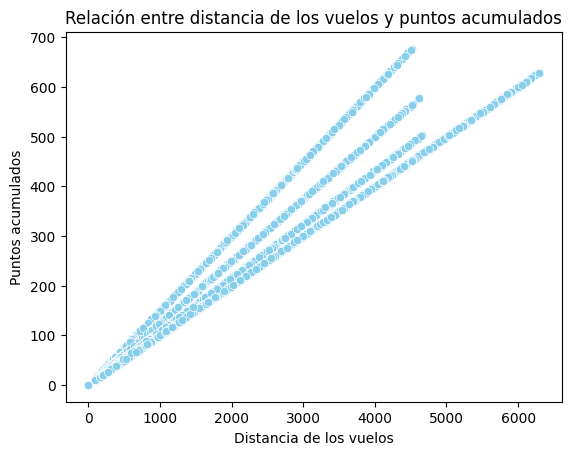

In [67]:
#¿Existe una relación entre la distancia de los vuelos y los puntos acumulados por los cliente?

sns.scatterplot(data=df, x="distance", y="points_accumulated", color="skyblue")
plt.title("Relación entre distancia de los vuelos y puntos acumulados")
plt.xlabel("Distancia de los vuelos")
plt.ylabel("Puntos acumulados");

Interpretación:

Hay una correlación positiva fuerte, cuanta más distacia tenga el vuelo más puntos acumula el cliente.

In [35]:
#¿Cuál es la distribución de los clientes por provincia o estado?

clientes_por_provincia = df["province"].value_counts().reset_index()# para contar la cantidad de clientes por provincia y convertirlo en un DataFrame
clientes_por_provincia

,province,count
0,Ontario,130258
1,British Columbia,106442
2,Quebec,79573
3,Alberta,23360
4,Manitoba,15900
5,New Brunswick,15352
6,Nova Scotia,12507
7,Saskatchewan,9861
8,Newfoundland,6244
9,Yukon,2679


C:\Users\dacil\AppData\Local\Temp\ipykernel_6720\4198453450.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y="province", palette="mako", order=orden_provincias);


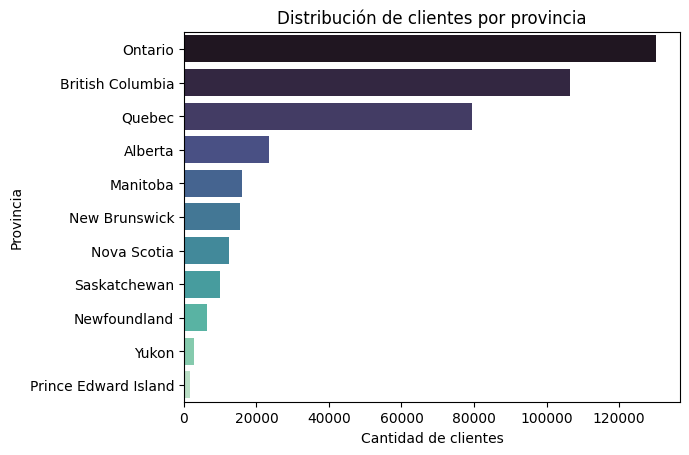

In [70]:
orden_provincias = df["province"].value_counts().index
sns.countplot(data=df, y="province", palette="mako", order=orden_provincias);
plt.title("Distribución de clientes por provincia");
plt.ylabel("Provincia");
plt.xlabel("Cantidad de clientes");

Interpretación:

Las tres provincias con más clientes son : Ontario, British Columbia y Quebec. Al investigar son las tres provincias con mas habitantes.

In [ ]:
#¿Cómo se compara el salario promedio entre los diferentes niveles educativos de los clientes?

salario_promedio_educacion = df.groupby("education")["salary"].mean().sort_values(ascending=False).reset_index()# para calcular el salario promedio por nivel educativo, ordenar los resultados de mayor a menor y convertirlo en un DataFrame

salario_promedio_educacion

,education,salary
0,Doctor,178403.675202
1,Master,103734.523724
2,Bachelor,72599.080913
3,College,66746.000000
4,High School or Below,61146.378165


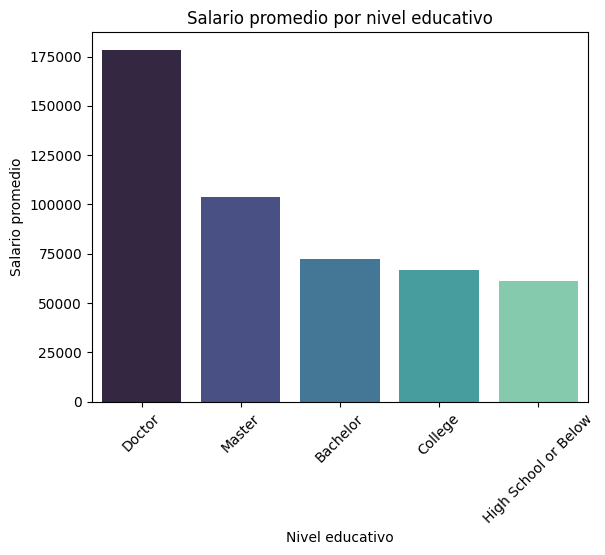

In [44]:
sns.barplot(data=salario_promedio_educacion, x="education", y="salary", palette="mako", hue= "education", legend=False, errorbar=None)
plt.title("Salario promedio por nivel educativo")
plt.xlabel("Nivel educativo")
plt.ylabel("Salario promedio")
plt.xticks(rotation=45);

Interpretación:

Existe una correlación positiva entre el de nivel educativo y el salario. Los estudios superiores tienen un salario mas alto.

In [ ]:
#¿Cuál es la proporción de clientes con diferentes tipos de tarjetas de fidelidad?

proporcion_clientes_por_tarjeta_fidelidad = round(df["loyalty_card"].value_counts(normalize=True)*100, 2).reset_index()# para calcular la proporción de clientes por tipo de tarjeta de fidelidad, multiplicar por 100 para obtener el porcentaje, redondear a 2 decimales y convertirlo en un DataFrame
proporcion_clientes_por_tarjeta_fidelidad

,loyalty_card,proportion
0,Star,45.51
1,Nova,33.90
2,Aurora,20.59


In [ ]:
datos = df["loyalty_card"].value_counts() # para contar la cantidad de clientes por tipo de tarjeta de fidelidad y convertirlo en un DataFrame

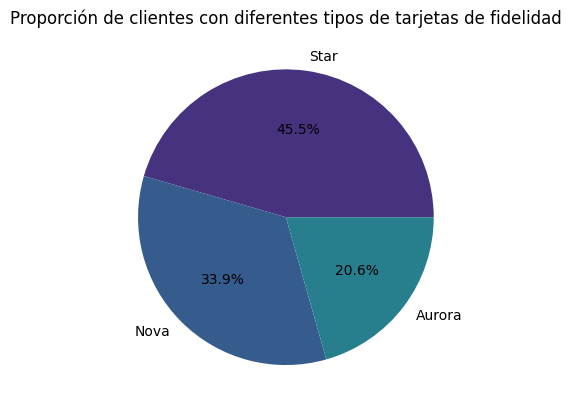

In [59]:
plt.pie(datos, labels=datos.index, autopct="%1.1f%%", colors=sns.color_palette("viridis"))
plt.title("Proporción de clientes con diferentes tipos de tarjetas de fidelidad");


interpretación:

Casi la mitad de los clientes están fidelizados en el nivel Star. A medida que subimos de categoría el volumen de clientes disminuye.

In [ ]:
# ¿Cómo se distribuyen los clientes según su estado civil y género?
estado_civil_genero = df.groupby("marital_status")["gender"].value_counts().reset_index()# para contar la cantidad de clientes por estado civil y género, y convertirlo en un DataFrame
estado_civil_genero

,marital_status,gender,count
0,Divorced,Female,30634
1,Divorced,Male,30128
2,Married,Male,117482
3,Married,Female,117363
4,Single,Female,54760
5,Single,Male,53393


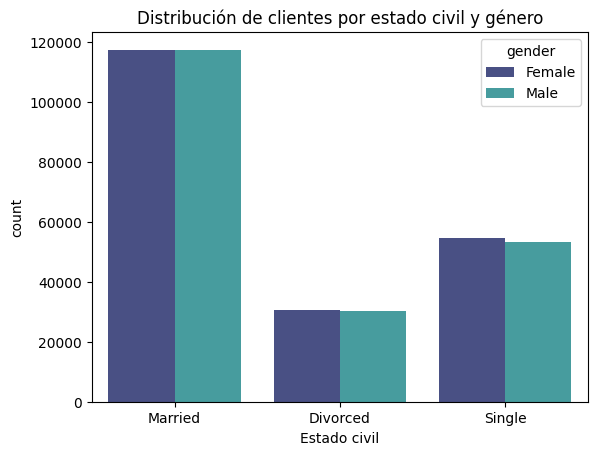

In [65]:
sns.countplot(data=df, x="marital_status", hue= "gender", palette="mako")
plt.title("Distribución de clientes por estado civil y género")
plt.xlabel("Estado civil");

Interpretación:

Más de la mitad de los clientes estan casados/as.